# Taller renta variable

In [1]:
# Importamos las librerías
import pandas as pd
import numpy as np

import gzip
import glob
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

C:\Users\mateo\anaconda31\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Ingesta y limpieza de datos

En los mercados bursátiles europeos modernos, la liquidez se encuentra dividida. La misma acción (ISIN) se negocia simultáneamente en la bolsa primaria (BME) y en varios Multilateral Trading Facilities (MTFs) como CBOE, Turquoise y Aquis.
Debido a esta división, surgen discrepancias temporales de precios. Una acción puede ofrecerse a la venta por 10,00 € en Turquoise mientras existe un comprador dispuesto a pagar 10,01 € en BME. Un operador de alta frecuencia (HFT) puede aprovechar esta situación **comprando barato y vendiendo caro de manera instantánea.**

- En la función read_data() (apartado 1.1) o read_data_rapido() (apartado 1.2) se leen los datos y se realiza el primer procesamiento de datos:
    - En las filas que comparten el mismo instante (epoch) nos quedamos únicamente con el último. Esto aplica tanto a los datos de las negociaciones como de los estados del mercado.
    - Convertimos el valor de la variable epoch a una variable de tiempo y la asignamos como índice de los dataframes de cada acción.

- En la función set_data() (apartado 1.1) y set_data_rapido() (apartado 1.2) se realiza:
    - La eliminación de los números mágicos. Es decir, los precios que no son válidos según el proveedor.
    - La eliminación de los estados de mercado que no se corresponden con los códigos que nos proporciona el proveedor.

### 1.1 Ejecución manual

Leemos los datos y los almacenamos en un diccionario donde la clave es el isin para identificar cada acción y el valor es el dataframe asociado. Esto se realiza para los datos QTE y STS.

- Para introducir los datos primero hay que definir cuantas empresas se quieren añadir. 
- Introducir manualmente para cada una de las acciones la **carpeta** en la que se incluyen los datos (por defecto "big") y su **isin**.
- En la carpeta small solo existen los datos de la acción (ES0113900J37).

In [2]:
##############################################################################################
                  # READ_DATA() -> Lectura de datos
##############################################################################################

def read_data(carpeta, isin = 'ES0113900J37'):
    
    if carpeta.lower() == 'small':
        root = "DATA_SMALL"
    elif carpeta.lower() == 'big':
        root = "DATA_BIG"
    else:
        return 'Introduce small o big'

    # Buscar todos los .csv.gz en cualquier subcarpeta
    paths = glob.glob(f"{root}/**/*.csv.gz", recursive=True)

    # Filtrar archivos que NO empiezan por TRD y sean del isin requerido
    paths_filtrados = [p for p in paths if not os.path.basename(p).startswith("TRD") and isin in os.path.basename(p)]
    
    dataframes_qte = []
    dataframes_sts = []
    
    paths_filtrados_qte = [p for p in paths_filtrados if '\\QTE_' in p]
    
    for path in paths_filtrados_qte:
        with gzip.open(path, "rt") as f:
            df_qte = pd.read_csv(f, sep=';', compression='gzip')
            dataframes_qte.append(df_qte)
    
    paths_filtrados_sts = [p for p in paths_filtrados if '\\STS_' in p]
    
    for path in paths_filtrados_sts:
        with gzip.open(path, "rt") as f:
            df_sts = pd.read_csv(f, sep=';', compression='gzip')
            dataframes_sts.append(df_sts)

    data_qte = pd.concat(dataframes_qte, ignore_index=True)
    data_sts = pd.concat(dataframes_sts, ignore_index=True)
    
    # Nos quedamos solo con el último sequence para las filas que comparten el mismo epoch (solo aplica a QTE)
    data_qte = data_qte.sort_values(by=['epoch', 'sequence'], ascending=[True, True])
    duplicates = data_qte.duplicated(subset='epoch', keep=False).sum()
    print(f"Found {duplicates} trades sharing the same microsecond.")
    # Nos quedamos con el último registro dentro de cada microsegundo
    data_qte = data_qte.drop_duplicates(subset='epoch', keep='last')
    
    # Nos quedamos solo con el último sequence para las filas que comparten el mismo epoch
    data_sts = data_sts.sort_values(by=['epoch', 'sequence'], ascending=[True, True])
    duplicates = data_sts.duplicated(subset='epoch', keep=False).sum()
    print(f"Found {duplicates} trades sharing the same microsecond.")
    # Nos quedamos con el último registro dentro de cada microsegundo
    data_sts = data_sts.drop_duplicates(subset='epoch', keep='last')
    
    # Calculamos la fecha a partir de epoch
    data_qte['ts'] = pd.to_datetime(data_qte['epoch'], unit='us')
    data_sts['ts'] = pd.to_datetime(data_sts['epoch'], unit='us')
    
    # Establecemos para los dos datasets el índice como el epoch pasado a fecha
    data_qte.set_index('ts', inplace=True)
    data_sts.set_index('ts', inplace=True)
    
    return data_qte, data_sts


##############################################################################################
                  # SET_DATA() -> Filtrado de datos
##############################################################################################

def set_data(qte_df, sts_df):
    
    # Hay que meter las condiciones de precios (QTE) y de estados del mercado (STS)
    # 1. Condiciones de precios
    price_cols = [c for c in qte_df.columns if c.startswith('px')]
    descartes = {666666.666, 999999.999, 999999.989, 999999.988, 999999.979, 999999.123}
    # Construimos máscara: True = fila válida
    mask_valid_price = ~qte_df[price_cols].isin(descartes).any(axis=1)
    print(f"Se eliminan {(~mask_valid_price).sum()} filas por números mágicos")
    qte_clean = qte_df[mask_valid_price].copy()
    
    # 2. Condiciones de estado de mercado
    allowed_status_map = {
        'AQEU': {5308427},
        'XMAD': {5832713, 5832756},
        'CEUX': {12255233},
        'TQEX': {7608181},
    }

    # Construimos máscara inicial False
    mask_status = pd.Series(False, index=sts_df.index)

    # Para mic no listados en allowed_status_map no permitimos trading (por seguridad)
    for mic, allowed_codes in allowed_status_map.items():
        mic_mask = (sts_df['mic'] == mic) & (sts_df['market_trading_status'].isin(allowed_codes))
        mask_status |= mic_mask
    print(f"Se han eliminado { (~mask_status).sum() } filas por estado del mercado no continuo / no addressable")
    sts_clean = sts_df[mask_status]
    
    return qte_clean, sts_clean

# Pensar si merece la pena tener esto así o fuera de una función porque cada vez que se entra se reunicia el diccionario
def extraer_data():
    num_activos = int(input('Introduce el número de activos a incorporar: '))
    dict_qte = {}
    dict_sts = {}
    
    for activo in range (num_activos):
        
        carpeta = input('Introduce la carpeta en la que se encuentran los datos (big o small): ')
        isin = input('Introduce el isin de la empresa a añadir: ')
        dataframes_qte, dataframes_sts = read_data(carpeta, isin)
        dict_qte[isin], dict_sts[isin] = set_data(dataframes_qte, dataframes_sts)
    
    return dict_qte, dict_sts

Para el desarrollo de la práctica se han utilizado los datos de las siguientes empresas, representadas por su isin:

- ES0113679I37 -> **Bankinter**
- ES0113860A34 -> **Sabadell**
- ES0113900J37 -> **Santander**
- ES0124244E34 -> **Mapfre**
- ES0178430E18 -> **Telefónica**

In [3]:
qte_clean, sts_clean = extraer_data()
qte_df, sts_df = qte_clean.copy(), sts_clean.copy()

Introduce el número de activos a incorporar: 5
Introduce la carpeta en la que se encuentran los datos (big o small): big
Introduce el isin de la empresa a añadir: ES0113679I37


C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:34: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_sts = pd.read_c

Found 13286 trades sharing the same microsecond.
Found 0 trades sharing the same microsecond.
Se eliminan 0 filas por números mágicos
Se han eliminado 18 filas por estado del mercado no continuo / no addressable
Introduce la carpeta en la que se encuentran los datos (big o small): big
Introduce el isin de la empresa a añadir: ES0113860A34


C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:34: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_sts = pd.read_c

Found 18540 trades sharing the same microsecond.
Found 0 trades sharing the same microsecond.
Se eliminan 1 filas por números mágicos
Se han eliminado 18 filas por estado del mercado no continuo / no addressable
Introduce la carpeta en la que se encuentran los datos (big o small): big
Introduce el isin de la empresa a añadir: ES0113900J37


...

Found 52565 trades sharing the same microsecond.
Found 0 trades sharing the same microsecond.
Se eliminan 1 filas por números mágicos
Se han eliminado 19 filas por estado del mercado no continuo / no addressable
Introduce la carpeta en la que se encuentran los datos (big o small): big
Introduce el isin de la empresa a añadir: ES0124244E34


C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:34: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_sts = pd.read_c

Found 6188 trades sharing the same microsecond.
Found 0 trades sharing the same microsecond.
Se eliminan 0 filas por números mágicos
Se han eliminado 18 filas por estado del mercado no continuo / no addressable
Introduce la carpeta en la que se encuentran los datos (big o small): big
Introduce el isin de la empresa a añadir: ES0178430E18


C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_7220\3753379025.py:34: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_sts = pd.read_c

Found 13039 trades sharing the same microsecond.
Found 0 trades sharing the same microsecond.
Se eliminan 4 filas por números mágicos
Se han eliminado 18 filas por estado del mercado no continuo / no addressable


# No ejecutar si no se dispone de memoria suficiente

### 1.2. Ejecución rápida

Existe una versión alternativa para leer todos los datos de la carpeta seleccionada. En este caso simplemente se pide la carpeta en la que se encuentran los datos.

- La opción **big** contiene los datos de todas las acciones disponibles.
- La opción **small** contiene solo los datos de una acción.

En ambas funciones, los datos se almacenan en formato diccionario. Cada dataframe constituye el valor de cada empresa, cuya llave es su propio isin, que identifica unívocamente cada acción).

In [2]:
##############################################################################################
                  # READ_DATA() -> Lectura de datos
##############################################################################################

def read_data_rapido(carpeta):
    
    if carpeta.lower() == 'small':
        root = "DATA_SMALL"
    elif carpeta.lower() == 'big':
        root = "DATA_BIG"
    else:
        return 'Introduce small o big'

    # Buscar todos los .csv.gz en cualquier subcarpeta
    paths = glob.glob(f"{root}/**/*.csv.gz", recursive=True)

    # Filtrar archivos que NO empiezan por TRD y sean del isin requerido
    paths_filtrados = [p for p in paths if not os.path.basename(p).startswith("TRD")]
    
    dataframes_qte = []
    dataframes_sts = []
    
    paths_filtrados_qte = [p for p in paths_filtrados if '\\QTE_' in p]
    
    for path in paths_filtrados_qte:
        with gzip.open(path, "rt") as f:
            df_qte = pd.read_csv(f, sep=';', compression='gzip')
            dataframes_qte.append(df_qte)
    
    paths_filtrados_sts = [p for p in paths_filtrados if '\\STS_' in p]
    
    for path in paths_filtrados_sts:
        with gzip.open(path, "rt") as f:
            df_sts = pd.read_csv(f, sep=';', compression='gzip')
            dataframes_sts.append(df_sts)

    data_qte = pd.concat(dataframes_qte, ignore_index=True)
    data_sts = pd.concat(dataframes_sts, ignore_index=True)
    
    # Nos quedamos solo con el último sequence para las filas que comparten el mismo epoch (solo aplica a QTE)
    data_qte = data_qte.sort_values(by=['epoch', 'sequence'], ascending=[True, True])
    duplicates = data_qte.duplicated(subset='epoch', keep=False).sum()
    print(f"Found {duplicates} trades sharing the same microsecond.")
    # Nos quedamos con el último registro dentro de cada microsegundo
    data_qte = data_qte.drop_duplicates(subset='epoch', keep='last')
    
    # Nos quedamos solo con el último sequence para las filas que comparten el mismo epoch (solo aplica a QTE)
    data_sts = data_sts.sort_values(by=['epoch', 'sequence'], ascending=[True, True])
    duplicates = data_sts.duplicated(subset='epoch', keep=False).sum()
    print(f"Found {duplicates} trades sharing the same microsecond.")
    # Nos quedamos con el último registro dentro de cada microsegundo
    data_sts = data_sts.drop_duplicates(subset='epoch', keep='last')
    
    # Calculamos la fecha a partir de epoch
    data_qte['ts'] = pd.to_datetime(data_qte['epoch'], unit='us')
    data_sts['ts'] = pd.to_datetime(data_sts['epoch'], unit='us')
    
    # Establecemos para los dos datasets el índice como el epoch pasado a fecha
    data_qte.set_index('ts', inplace=True)
    data_sts.set_index('ts', inplace=True)
    
    return data_qte, data_sts


##############################################################################################
                  # SET_DATA() -> Filtrado de datos
##############################################################################################

def set_data_rapido(qte_df, sts_df):
    
    # Hay que meter las condiciones de precios (QTE) y de estados del mercado (STS)
    # 1. Condiciones de precios
    price_cols = [c for c in qte_df.columns if c.startswith('px')]
    descartes = {666666.666, 999999.999, 999999.989, 999999.988, 999999.979, 999999.123}
    # Construimos máscara: True = fila válida
    mask_valid_price = ~qte_df[price_cols].isin(descartes).any(axis=1)
    print(f"Se eliminan {(~mask_valid_price).sum()} filas por números mágicos")
    qte_clean = qte_df[mask_valid_price].copy()
    
    # 2. Condiciones de estado de mercado
    allowed_status_map = {
        'AQEU': {5308427},
        'XMAD': {5832713, 5832756},
        'CEUX': {12255233},
        'TQEX': {7608181},
    }

    # Construimos máscara inicial False
    mask_status = pd.Series(False, index=sts_df.index)

    # Para mic no listados en allowed_status_map no permitimos trading (por seguridad)
    for mic, allowed_codes in allowed_status_map.items():
        mic_mask = (sts_df['mic'] == mic) & (sts_df['market_trading_status'].isin(allowed_codes))
        mask_status |= mic_mask
    print(f"Se han eliminado { (~mask_status).sum() } filas por estado del mercado no continuo / no addressable")
    sts_clean = sts_df[mask_status]
    
    return qte_clean, sts_clean

# Pensar si merece la pena tener esto así o fuera de una función porque cada vez que se entra se reunicia el diccionario
def extraer_data_rapido():
    carpeta = input('Introduce la carpeta en la que se encuentran los datos: ')
    dict_qte = {}
    dict_sts = {}
    
    dataframes_qte, dataframes_sts = read_data_rapido(carpeta)
    lista_isin = dataframes_qte['isin'].unique()
    
    for isin in lista_isin:
        dict_qte[isin], dict_sts[isin] = set_data_rapido(dataframes_qte[dataframes_qte['isin']==isin], dataframes_sts[dataframes_sts['isin']==isin])
    
    return dict_qte, dict_sts

In [20]:
# Ejecutamos la lectura y 
qte_df, sts_df = extraer_data_rapido()

Introduce la carpeta en la que se encuentran los datos: big


C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\3314206485.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\3314206485.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\3314206485.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\3314206485.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.read_csv(f, sep=';', compression='gzip')
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\3314206485.py:27: RuntimeWarning: compression has no effect when passing a non-binary object as input.
  df_qte = pd.r

Found 664349 trades sharing the same microsecond.
Found 2125 trades sharing the same microsecond.
Se eliminan 0 filas por números mágicos
Se han eliminado 0 filas por estado del mercado no continuo / no addressable
Se eliminan 3 filas por números mágicos
Se han eliminado 2 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 4 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 2 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 0 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 2 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 2 filas por estado del mercado no continuo / no addressable
Se eliminan 0 filas por números mágicos
Se han eliminado 2 filas por estado del mer

### 1.3. Cruce entre los datos de cotizaciones y estado del mercado

Una vez tenemos los datos de las negociaciones de cada acción (qte_df) y de los estados del mercado (sts_df). En este apartado lo que hacemos es filtrar los datos originales para quedarnos con los que corresponden el periodo de **negociación contínua** del mercado.

En este caso solo nos dan el código de la apertura del mercado. Como no se ha especificado cuando es el cierre de los mercados, porque difieren en horas, no he considerado filtrar los datos por el cierre porque no dispongo de esa información.

In [21]:
def cruce_qte_sts(qte_df, sts_df):
    qte = {}
    
    for key in qte_df.keys():
        qte_df[key] = qte_df[key].sort_values("ts")
        sts_df[key] = sts_df[key].sort_values("ts")
        # Perform the As-Of Merge
        df_merge = pd.merge_asof(
            qte_df[key],             # Left Table (High Frequency - Trades)
            sts_df[key][['mic', 'market_trading_status']],              # Right Table (Low Frequency - News)
            on='ts',                # The Time Column
            by='mic',
            direction='backward'    # Look into the past, never the future!
        )                  # Así nos quedamos con las fechas
    
        # Eliminamos las filas que no tienen un número en la variable del estado del mercado
        qte[key] = df_merge.dropna(subset=['market_trading_status'])
        qte[key].set_index('ts', inplace=True)
    
    return qte

In [22]:
# Realizamos el cruce entre los dataframes qte y sts para quedarnos con las operaciones que se encuentran en los estados
# del mercado válidos por el proveedor
qte = cruce_qte_sts(qte_df, sts_df)

## 2. Crear la "Cinta Consolidada"

Para cada isin guardamos los datos de precios y cantidades de oferta y demanda para cada mercado. Como consecuencia, se establece un doble índice para los datos: **ts y mic**. 

El resultado es un diccionario donde las claves son los isin de cada acción y el valor es la cinta consolidada correpondiente de cada acción. 

In [23]:
def final_data_qte(df):
    # Generamos el dataframe donde el índice es ts y las columnas son la mejor oferta y demanda de cada mercado
    return df.pivot(columns='mic', values=['qty_bid_0', 'px_bid_0', 'qty_ask_0', 'px_ask_0']).ffill()

In [24]:
# Generamos el diccionario que contiene las "cintas consolidadas" de cada uno de los isin
qte_consolidado = {}

for isin in qte.keys():
    qte_consolidado[isin] = final_data_qte(qte[isin])

## 3. Generación de señales

### 3.1. Condición de arbitraje

Función que determina la existencia o no de arbitraje. Existe arbitraje si el precio de oferta máximo es mayor que el precio de demanda mínimo (comprar barato y vender caro).

In [ ]:
def arbitraje(df):
    
    oferta_max_global = df['px_bid_0'].max(axis = 1)
    demanda_min_global = df['px_ask_0'].min(axis = 1)
    
    return oferta_max_global > demanda_min_global

### 3.2. Cálculo de beneficio

Obtenemos el diccionario donde cada clave incluye el dataframe final para cada isin. Se almacenan las variables:

- **px_bid**: Mejor precio de oferta
- **px_ask**: Mejor precio de demanda
- **spread**: px_bid - px_ask
- **cantidad_bid**: Número de acciones que esta dispuesto a comprar la oferta
- **cantidad_ask**: Número de acciones que esta dispuesto a vender la demanda
- **cantidad**: min(cantidad_bid, cantidad_ask)
- **beneficio**: spread*cantidad
- **arbitraje** (booleana): Indica si hay arbitraje o no

Las opciones de arbitraje se identifican en la variable arbitraje **(si arbitraje = True)**

Como resultado se obtiene un nuevo diccionario cuyas claves son los isin de cada empresa y los valores son los dataframes que contienen la estructura de variables desarrolladas en este cuadro de texto.

Para rellenar el diccionario, no ha sido posible añadir todas las acciones. Para ello, se han filtrado las acciones por las que presentan dataframes que no sean vacíos o no tengan todos sus valores nulos (el único de estos casos es el isin ES0183304080).

In [25]:
def arbitraje_dataset(df):
    
    df['arbitraje'] = df['px_bid'] > df['px_ask']
    
    return df

def beneficio(qte_data):
    # Obtenemos el beneficio en cada instante temporal
    qte_final = qte_data.drop(columns=qte_data.columns)
    
    qte_final['px_bid'] = qte_data['px_bid_0'].max(axis = 1)
    qte_final['px_ask'] = qte_data['px_ask_0'].min(axis = 1)
    qte_final['spread'] = qte_final['px_bid'] - qte_final['px_ask']

    # Obtenemos la cantidad que puede intercambiarse en el mercado en cada momento
    mercado_max_bid = qte_data['px_bid_0'].idxmax(axis=1)   # Mercado con el mejor bid
    mercado_min_ask = qte_data['px_ask_0'].idxmin(axis=1)   # Mercado con el mejor ask
    
    #cantidad_bid = []
    #cantidad_ask = []  
    
    #for i in range(qte_data.shape[0]):
    # Si no existe mejor mercado, ponemos 0
    #    if pd.isna(mercado_max_bid[i]):
    #        cantidad_bid.append(0)
    #    else:
    #        cantidad_bid.append(qte_data['qty_bid_0'][mercado_max_bid[i]][i])

    #    if pd.isna(mercado_min_ask[i]):
    #        cantidad_ask.append(0)
    #    else:
    #        cantidad_ask.append(qte_data['qty_ask_0'][mercado_min_ask[i]][i])
    
    #cantidad_oferta = pd.DataFrame(data = cantidad_bid, index=qte_final.index)
    #cantidad_demanda = pd.DataFrame(data = cantidad_ask, index=qte_final.index)
    
    # Obtener el índice numérico de la columna MIC (Level 1 de las columnas)
    mic_map = {mic: i for i, mic in enumerate(qte_data.columns.get_level_values(1).unique())}
    
    # Mapear los nombres de MIC (e.g., 'XMAD') a sus posiciones en la matriz (e.g., 0, 1, 2...)
    bid_indices = [mic_map[mic] for mic in mercado_max_bid.fillna(mercado_max_bid.mode()[0])]
    ask_indices = [mic_map[mic] for mic in mercado_min_ask.fillna(mercado_min_ask.mode()[0])]
    
    # Para la cantidad BID, necesitamos la submatriz de 'qty_bid_0'
    bid_data = qte_data['qty_bid_0'].values
    
    # Para la cantidad ASK, necesitamos la submatriz de 'qty_ask_0'
    ask_data = qte_data['qty_ask_0'].values
    
    # Indexación avanzada de NumPy
    row_indices = np.arange(len(qte_data))
    
    qte_final['cantidad_bid'] = bid_data[row_indices, bid_indices]
    qte_final['cantidad_ask'] = ask_data[row_indices, ask_indices]
    
    #qte_final['cantidad_bid'] = cantidad_oferta
    #qte_final['cantidad_ask'] = cantidad_demanda
    qte_final['cantidad'] = np.minimum(qte_final['cantidad_bid'], qte_final['cantidad_ask'])
    qte_final['beneficio'] = qte_final['spread']*qte_final['cantidad']
    
    qte_final = arbitraje_dataset(qte_final)
    qte_final.columns = qte_final.columns.get_level_values(0)
    
    return qte_final

In [26]:
# Obtenemos el dataframe final para cada isin. Incluyendo las columnas de precios, cantidades, spread, beneficio y arbitraje
dict_beneficio = {}

for key in qte_consolidado.keys():
    if len(qte_consolidado[key])!=0:
        if key!='ES0183304080':
            #print(key)
            dict_beneficio[key] = beneficio(qte_consolidado[key])

C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\2788637271.py:17: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  mercado_min_ask = qte_data['px_ask_0'].idxmin(axis=1)   # Mercado con el mejor ask
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\2788637271.py:16: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  mercado_max_bid = qte_data['px_bid_0'].idxmax(axis=1)   # Mercado con el mejor bid
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\2788637271.py:17: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  mercado_min_ask = qte_data['px_ask_0'].idxmin(axis=1)   # Mercado con el mejor ask
C:\Users\mateo\AppData\Local\Temp\ipykernel_18288\2788637271.py:16:

### 3.3. Borde ascendente

Nos quedamos con los datos en los que existe arbitraje (arbitraje = True) y eliminamos los datos duplicados quedándonos con la primera aparición dentro de un conjunto de observaciones que sean consecutivas.

Aquí se determinan todas las oportunidades de arbitraje sin importar cuanto sea su spread.

In [27]:
def oportunidades_arbitraje(df):
    # Filtrar solo arbitrajes
    df_ar = df[df['arbitraje'] == True].copy()

    # Quitar duplicados consecutivos basados en todas las columnas
    df_ar = df_ar.loc[(df_ar != df_ar.shift()).any(axis=1)]

    return df_ar

In [28]:
# Obtenemos el número total de opciones de arbitraje disponibles (columna arbitraje = True)
dict_beneficio_total = {}

for key in dict_beneficio.keys():
    dict_beneficio_total[key] = oportunidades_arbitraje(dict_beneficio[key])

In [13]:
dict_beneficio_total['ES0113900J37']

,px_bid,px_ask,spread,cantidad_bid,cantidad_ask,cantidad,beneficio,arbitraje
ts,,,,,,,,
2025-11-07 08:00:19.476091,8.990,8.988,0.002,378.0,2696.0,378.0,0.756,True
2025-11-07 08:00:19.494971,8.990,8.988,0.002,269.0,2696.0,269.0,0.538,True
2025-11-07 08:00:19.676541,8.990,8.985,0.005,269.0,715.0,269.0,1.345,True
2025-11-07 08:00:19.676545,8.990,8.984,0.006,269.0,1985.0,269.0,1.614,True
2025-11-07 08:00:19.689067,8.990,8.985,0.005,269.0,2816.0,269.0,1.345,True
...,...,...,...,...,...,...,...,...
2025-11-07 16:35:05.856936,8.847,8.832,0.015,5735761.0,767.0,767.0,11.505,True
2025-11-07 16:35:05.856937,8.850,8.832,0.018,5801210.0,767.0,767.0,13.806,True
2025-11-07 16:35:10.955681,8.849,8.832,0.017,5801210.0,767.0,767.0,13.039,True


### 3.4. Simplificación

Mostramos el spread de todas las empresas disponibles en un gráfico. Se puede apreciar que es en el cierre donde hay oportunidades de arbitraje.

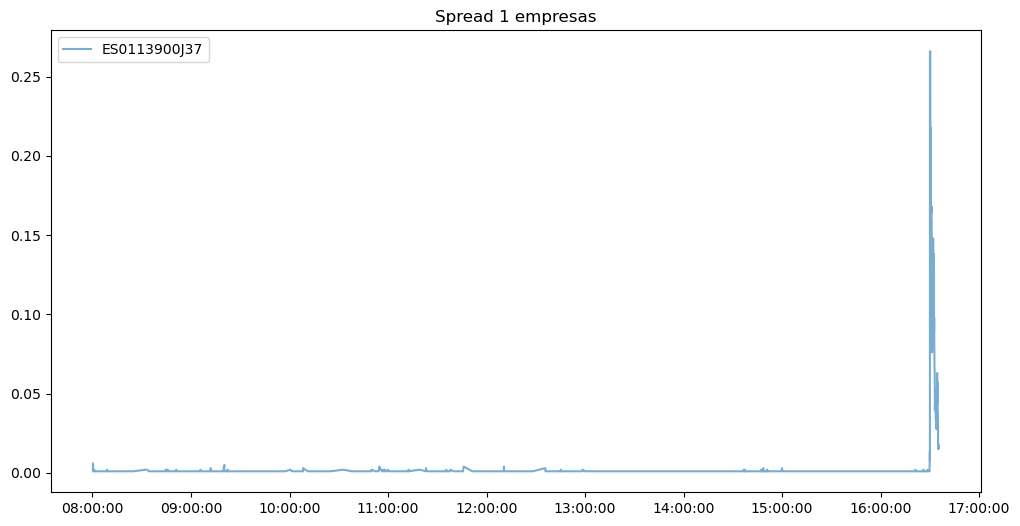

In [14]:
# Mostramos la evolución de los spreads a lo largo del día para cada uno de los isin
plt.figure(figsize=(12, 6))

for key in dict_beneficio_total.keys():
    plt.plot(dict_beneficio_total[key].index, dict_beneficio_total[key]['spread'], label = key,alpha=0.6)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.title("Spread " + str(len(dict_beneficio_total.keys())) + ' empresas')
plt.legend()
plt.show()

## 4. Simulación de latencias

La forma de calcular el beneficio esperado para cada nivel de latencia (y para cada isin) es la siguiente:

- Realizamos un merge_asof() entre los diccionarios: 
    - **dict_beneficio** que contiene todos los datos de precios, cantidades, spread, beneficio y arbitraje.
    - **dict_beneficio_total** que es un subconjunto de dict_beneficio ya que solo tiene en cuenta los casos en los que la columna arbitraje es True.
    
- Tras ello, calculamos el mínimo entre las cantidades en el momento en el que se lanza la orden y el momento en el que se efectua. Este cálculo nos permitirá saber cual es el número de acciones que realmente están disponibles para negociar en el mercado.

- Por último, el beneficio se calcularía como el producto entre la cantidad (obtenida en el punto anterior) y el spread (spread_y) en el momento que se efectua la operación.

- Se han incluido dos parámetros adicionales:
    - Tolerancia: Es un filtro para considerar los spreads que sean mayores que la tolerancia. Lo he incluido porque hay muchos casos donde el spread es muy pequeño y la relación beneficio-riesgo puede no compensar. Por defecto es 0.
    - Coste: Es una simulación del caso en el que las operaciones conlleven un coste (comisiones) asociado. Por defecto es 0.

In [29]:
def calculo_beneficios(dict_beneficio, dict_beneficio_total, tolerancia = 0, coste = 0):
    latencias = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
    resultados_por_key = {}
    
    for key in dict_beneficio_total.keys():
        # Nos quedamos con los spread mayores que la tolerancia. No consideraremos los spreads que sean menores que la toleracia
        arbitrajes = dict_beneficio_total[key][dict_beneficio_total[key]['spread']>tolerancia].copy()
        ticks = dict_beneficio[key].copy()             # todos los ticks
        
        resultados_key = {}

        for L in latencias:
            delta = pd.to_timedelta(L, unit="us")
            #delta = pd.to_timedelta(60*L, unit="us")

            # timestamp futuro
            arbitrajes["ts_future"] = arbitrajes.index + delta

            # Uso de merge asof para quedarnos con el spread en el momento en el que se hace efectiva la operación
            # Es decir, el instante de ejecución más la latencia
            merged = pd.merge_asof(
                left=arbitrajes.sort_values("ts_future"),
                right=ticks.sort_index(),
                left_on="ts_future",
                right_index=True,
                direction="backward"   # buscamos el primer tick DESPUÉS del tiempo futuro
            )
            # Elegimos el mínimo de la cantidad de acciones disponibles en el momento en el que se ejecuta la operación
            # y el momento en el que se hace efectiva la operación
            cantidad = np.minimum(merged["cantidad_x"], merged["cantidad_y"])
            beneficio_total = (cantidad*(merged["spread_y"]-coste)).sum().round(2)
            resultados_key[L] = beneficio_total

        resultados_por_key[key] = resultados_key
    
    return resultados_por_key

Obtenemos el diccionario final cuyas claves son los isin y sus valores son, a su vez, otro diccionario. En este segundo diccionario, las claves son los diferentes valores de latencia y los valores son los beneficios esperados para cada nivel de latencia.

In [30]:
# Obtenemos el diccionario que guarda para cada isin la "tabla del dinero" en formato diccionario
resultados_por_key = calculo_beneficios(dict_beneficio, dict_beneficio_total)

### 4.1. La tabla del dinero

Calculamos la tabla del dinero que consiste en agrupar para cada empresa (isin) el beneficio esperado según diferentes valores de latencia. Los índices son los isin y las columnas son los diferentes valores de latencia.

In [31]:
# Transformamos la "tabla del dinero" de diccionario a dataframe
tabla_del_dinero = pd.DataFrame.from_dict(resultados_por_key, orient='index')
tabla_del_dinero.index.name = "isin"
tabla_del_dinero.columns.name = "latencia_us"

tabla_del_dinero

latencia_us,0,100,500,1000,2000,3000,4000,5000,10000,15000,20000,30000,50000,100000
isin,,,,,,,,,,,,,,
AU000000BKY0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
ES0105027009,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,28.40,0.00
ES0105066007,145160.23,144832.78,144352.69,144091.62,143818.31,143798.77,143786.83,143744.46,143568.96,143137.83,143044.91,142792.88,141532.11,140640.59
ES0105079000,410.30,378.20,254.10,237.40,238.70,239.30,231.90,212.50,165.90,174.00,188.00,197.10,203.80,200.00
ES0105130001,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FR0010251744,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
FR0011036268,448349.96,447755.07,447755.07,447755.07,447755.07,447755.07,447755.07,447760.18,447760.18,447760.18,447760.18,447760.18,447719.87,447704.36
FR0011042753,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [38]:
tabla_del_dinero.sum().values

array([765507.23, 763963.31, 762798.78, 762350.83, 761960.14, 761590.78,
       761532.9 , 761363.89, 760651.73, 760026.26, 760032.29, 759372.69,
       758296.36, 757528.95])

### 4.2. Gráfico de decaimiento

Gráfico que muestra la latencia (eje x) versus el beneficio esperado (eje y).

Se puede apreciar que la latencia apenas afecta al beneficio esperado. Tiene cierto impacto cuanto menor es la latencia pero a medida que aumenta se produce un estancamiento del beneficio esperado.

Esto puede deberse a que el mercado tarda en corregir estas situaciones de arbitraje más de la cuenta. Quizás haya sido consecuencia de no haber tenido disponible un filtro que nos permitieran tratar los precios y fechas de cierre del mercado. 

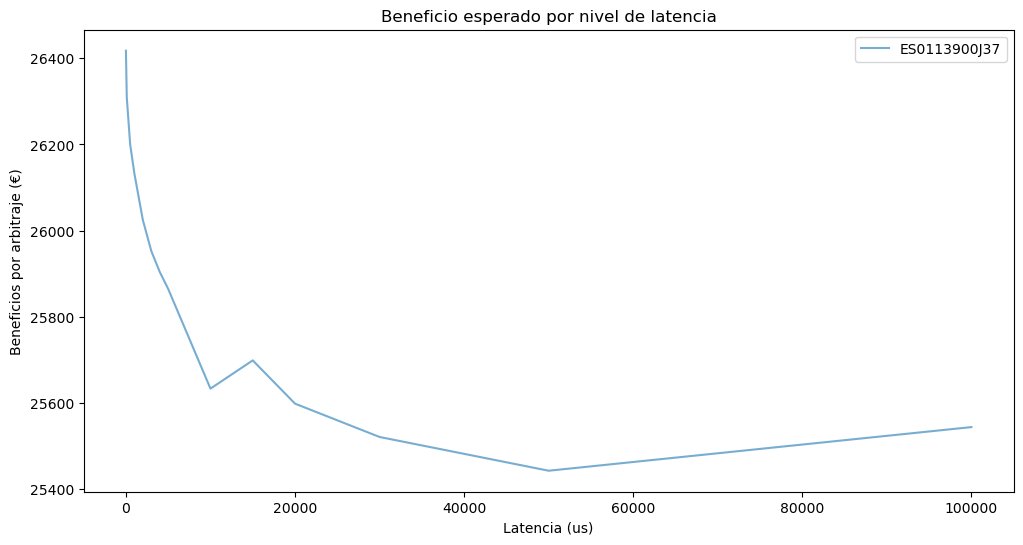

In [18]:
# Mostramos la relación entre la latencia y el beneficio esperado para cada isin
plt.figure(figsize=(12, 6))

for key in resultados_por_key.keys():
    plt.plot(resultados_por_key[key].keys(), resultados_por_key[key].values(), label = key, alpha=0.6)

plt.title('Beneficio esperado por nivel de latencia')
plt.xlabel('Latencia (us)')
plt.ylabel('Beneficios por arbitraje (€)')
plt.legend()
plt.show()

### 4.3 Oportunidades principales

Ordenamos las empresas en función del beneficio esperado con una latencia igual a cero y mostramos las cinco primeras.

In [17]:
# Mostramos los cinco mejores beneficios esperados por isin con latencia = 0
oportunidades_principales = tabla_del_dinero[0].sort_values(ascending=False)
oportunidades_principales.head(5)

isin
ES0113900J37    26417.56
ES0113860A34    14952.34
ES0124244E34     4173.68
ES0113679I37     2756.21
ES0178430E18     2160.31
Name: 0, dtype: float64

**Todas estas conclusiones se han obtenido para estas cinco acciones. Podrían ser diferentes para otras acciones.**

## Respuesta a las preguntas del enunciado

**1. ¿Siguen existiendo oportunidades de arbitraje en las acciones españolas?**

Sí, especialmente en las aperturas y cierres del mercado.

**2. ¿Cuál es el beneficio teórico máximo (suponiendo latencia cero)?**

Para el número de acciones utilizados (los cinco, no todos por no tener suficiente memoria), el mayor beneficio esperado es el del isin ES0113900J37 que corresponde a la empresa Santander (ticker = SAN).

**3. La curva de "Decaimiento por Latencia"**: ¿Qué tan rápido desaparece este beneficio a medida que nuestro sistema de trading se vuelve más lento (de 0 µs a 100 ms)?

No se aprecia en este caso y decaimiento significativo a medida que aumenta la latencia. Si que es cierto que hay un descenso más pronunciado en los casos en los que la latencia es menor (de 0 a unos 5000 us) pero a partir de ahí se aprecia un estancamiento del beneficio esperado. El efecto del aumento de la latencia por encima de los 5.000 us hasta los 100.000 no tiene un gran impacto.

In [19]:
import gc
gc.collect()

3160